In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

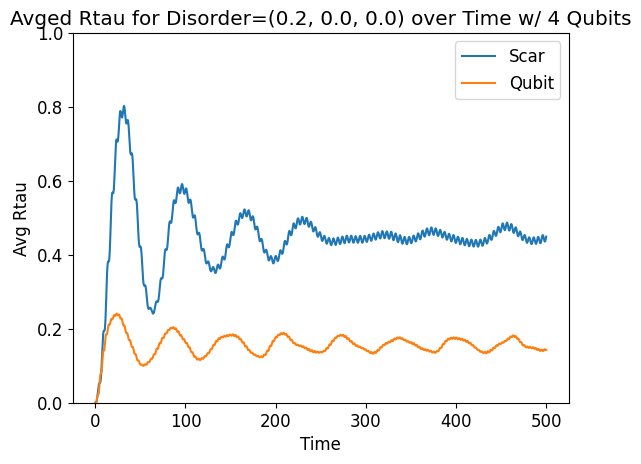

C:\Users\idden\AppData\Local\Temp\ipykernel_26812\1470750983.py:51: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, plotScar / plotQubit, label="Ratio")


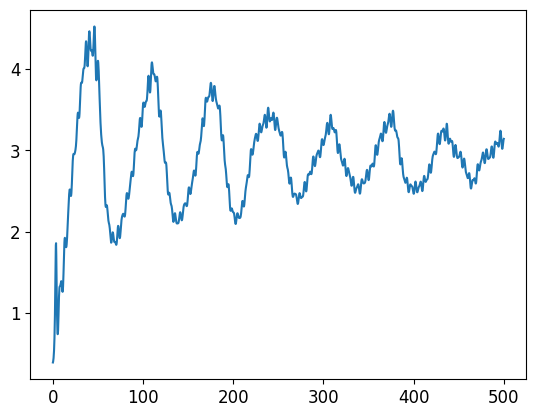

In [6]:
wd = 0.6365091993031
wm = 1.0
tlist = np.linspace(0, 500, 2000)
dz = 0.2
dy = 0.0
dx = 0.0
N = 4
reals = 100
amp = 0.1
args = {"A": amp, "omega": wd}
qargs = {"A": amp, "omega": wm}

scar_dR = []
qubit_dR = []

# random diagonal with zero mean
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[dz, dy, dx], random_seed=True)

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])

    Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
    scar_dR.append(Rtau)

for _ in range(reals):
    qH0, qH1, qeigvals, qeigstates = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], random_seed=True, sigz_ham=True)
    qband = qeigvals[-1] - qeigvals[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])

    qRtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
    qubit_dR.append(qRtau)

scar_dR = np.array(scar_dR)
plotScar = np.mean(scar_dR, axis=0)

qubit_dR = np.array(qubit_dR)
plotQubit = np.mean(qubit_dR, axis=0)

plt.plot(tlist, plotScar, label="Scar")
plt.plot(tlist, plotQubit, label="Qubit")
plt.title(f"Avged Rtau for Disorder={dz, dy, dx} over Time w/ {N} Qubits")
plt.ylabel("Avg Rtau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.plot(tlist, plotScar / plotQubit, label="Ratio")
plt.show()

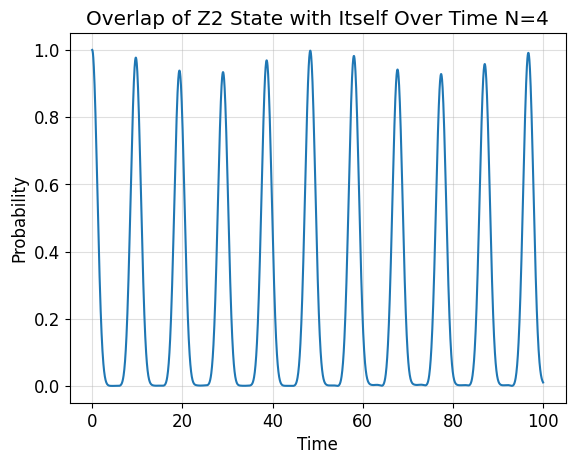

In [5]:
plotProbZ2Time(H0, N, psi0, t=100)